# 유닛 이코노믹스 실습

본문에서 설명한 LTV:CAC 계산과 다양한 형태의 보정을 직접 실습해 보겠습니다.

### 실습용 데이터 준비

실습에는 3개의 테이블이 필요합니다. 마케팅 비용, 유저 테이블, 그리고 결제 로그인데요.
각각 CAC 계산의 분자(마케팅 비용)와 분모(유저 테이블), 그리고 LTV 계산의 원천(결제 로그)이
됩니다.

| 파일 | 컬럼 | 설명 |
| --- | --- | --- |
| `marketing_costs.csv` | month, channel, media_cost_krw, other_cost_krw | 월×채널 마케팅 비용. other는 에이전시 수수료·소재 제작비 |
| `users.csv` | user_id, channel, signup_date | 유입 유저 명부 — **결제 안 한 유저도 포함** |
| `payments.csv` | user_id, payment_date, amount_krw | 결제 건별 로그. 금액은 전부 '매출' |

마케팅 비용을 구성하는 채널은 검색, 디스플레이, 리타겟팅, 브랜드, 오가닉까지 다섯 개입니다.
노트북 환경 구성은 아래와 같습니다. 본문 2.1의 변동비 가정(합계 35%)에 따라 공헌이익률
65%를 상수로 선언해 두고 시작합니다.

In [1]:
# 의존성 설치
%pip install -q -r requirements.txt

# 실습 데이터 환경 구성
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect()
for t in ["marketing_costs", "users", "payments"]:
    con.execute(f"CREATE TABLE {t} AS SELECT * FROM read_csv_auto('data/{t}.csv')")

# 공헌이익률 65% — 본문 2.1의 변동비 가정(수수료 15% + 판촉 10% + 결제·CS 5% + 인프라 5%)
CM_RATIO = 0.65


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /private/tmp/claude-501/-Users-leo-leo-project-bye-summer-book2/8de1c3bd-44e1-4f5f-aea2-3f0d5e5f7818/scratchpad/vizenv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


### 1) 채널별 CAC — 매체비 기준 vs fully-loaded

2025년 4월 한 달을 기준으로 채널별 CAC를 계산합니다. 포인트는 두 가지인데요. 첫째,
오가닉은 광고비가 없으므로 제외합니다. (SQL에서 비용 테이블과 조인하는 순간 분모에서
자연스럽게 빠집니다.) 둘째, 매체비만 반영한 CAC(cac_media)와 기타 비용까지 포함한
CAC(cac_fully_loaded)를 구분해서 계산합니다.

In [2]:
query = """
SELECT c.channel
     , u.new_users
     , ROUND(c.media_cost_krw / u.new_users)                      AS cac_media
     , ROUND((c.media_cost_krw + c.other_cost_krw) / u.new_users) AS cac_fully_loaded
FROM marketing_costs c
JOIN (
    SELECT channel, COUNT(*) AS new_users
    FROM users
    WHERE date_trunc('month', signup_date) = DATE '2025-04-01'
    GROUP BY channel
) u USING (channel)                    -- 오가닉은 비용 행이 없어 여기서 빠진다
WHERE c.month = DATE '2025-04-01'
ORDER BY u.new_users DESC
"""
cac = con.execute(query).df()
cac

,channel,new_users,cac_media,cac_fully_loaded
0,search,1000,9890.0,11500.0
1,brand,750,22389.0,28000.0
2,display,500,5016.0,5700.0
3,retargeting,250,3240.0,3600.0


In [3]:
# 유료 전체 CAC — 채널 합산 (본문 2.2의 12,000원 → 14,500원)
apr = con.execute("""
    SELECT SUM(media_cost_krw) AS media, SUM(media_cost_krw + other_cost_krw) AS fully
    FROM marketing_costs WHERE month = DATE '2025-04-01'
""").df().iloc[0]
n_paid = cac.new_users.sum()
print(f"2025-04 유료 유입        : {n_paid:,}명")
print(f"매체비 기준 CAC          : {apr.media / n_paid:,.0f}원")
print(f"fully-loaded CAC        : {apr.fully / n_paid:,.0f}원  (+{apr.fully / apr.media - 1:.0%})")

2025-04 유료 유입        : 2,500명
매체비 기준 CAC          : 12,000원
fully-loaded CAC        : 14,500원  (+21%)


본문 2.2에서 봤던 12,000원 → 14,500원이 그대로 나옵니다. 매체비만 보면 마케팅 리드의
계산이 맞지만, 에이전시 수수료와 소재 제작비를 얹는 순간 CAC가 20% 넘게 올라가는 게
보입니다.

### 2) LTR을 LTV(공헌이익)로 — 성숙 코호트 백테스트

LTV를 예측 모델 없이 계산하는 간단한 방법은, 획득한 지 3년이 지난 코호트의 결제를
실제로 다 세어보는 것입니다. (4장에서 설명한 성숙 코호트 기반 집계) 2022-07~2023-06에
유입된 유저들의 36개월 누적 결제금액(LTR)을 구하고, 공헌이익률 65%를 곱해 LTV로 바꿉니다.

In [4]:
query = f"""
WITH mature AS (             -- 획득 후 36개월이 다 지난 코호트만
    SELECT user_id, channel, date_trunc('month', signup_date) AS cohort_month
    FROM users
    WHERE signup_date < DATE '2023-07-01'
),
rev AS (                     -- 유저별 36개월 누적 결제금액 (미결제 유저는 0)
    SELECT m.channel, m.user_id, COALESCE(SUM(p.amount_krw), 0) AS ltr_36m
    FROM mature m
    LEFT JOIN payments p
      ON p.user_id = m.user_id
     AND p.payment_date < m.cohort_month + INTERVAL 36 MONTH
    GROUP BY 1, 2
)
SELECT channel
     , COUNT(*)                          AS users
     , ROUND(AVG(ltr_36m))               AS ltr
     , ROUND(AVG(ltr_36m) * {CM_RATIO})  AS ltv_cm      -- LTV(공헌이익)
FROM rev
GROUP BY channel
ORDER BY ltv_cm DESC
"""
ltv = con.execute(query).df()
ltv

,channel,users,ltr,ltv_cm
0,search,1440,50766.0,32998.0
1,organic,1440,39989.0,25993.0
2,retargeting,360,36974.0,24033.0
3,brand,1080,36926.0,24002.0
4,display,720,9080.0,5902.0


In [5]:
# 마케팅 리드의 캐스케이드 재현: 3.1 → 2.0 → 1.7 (유료 유입 기준)
paid_ltr = ltv[ltv.channel != "organic"].pipe(
    lambda d: (d.ltr * d.users).sum() / d.users.sum())
paid_ltv = paid_ltr * CM_RATIO

print(f"유료 유입 유저의 LTR         : {paid_ltr:,.0f}원")
print(f"LTV(공헌이익) = LTR x 65%   : {paid_ltv:,.0f}원")
print()
print(f"[1] LTR  / 매체비 CAC        : {paid_ltr / 12000:.1f}   <- 마케팅 리드의 계산")
print(f"[2] LTV  / 매체비 CAC        : {paid_ltv / 12000:.1f}   <- 공헌이익으로 교체")
print(f"[3] LTV  / fully-loaded CAC : {paid_ltv / 14500:.1f}   <- 비용을 fully-loaded로")

유료 유입 유저의 LTR         : 36,898원
LTV(공헌이익) = LTR x 65%   : 23,983원

[1] LTR  / 매체비 CAC        : 3.1   <- 마케팅 리드의 계산
[2] LTV  / 매체비 CAC        : 2.0   <- 공헌이익으로 교체
[3] LTV  / fully-loaded CAC : 1.7   <- 비용을 fully-loaded로


본문 표 1→2→3의 흐름이 데이터에서 그대로 복원됐습니다. 매출 기준으로는 LTV:CAC를 봤을
때는 3.1이었지만, 지표의 '단위'를 공헌이익과 fully-loaded로 맞추고 나니 1.7이 됐습니다.

### 3) 채널별로 쪼개보기

실습 1의 CAC와 실습 2의 LTV를 채널 단위로 붙이면 본문 2.3의 채널 표가 완성됩니다.

In [6]:
table = cac.merge(ltv[["channel", "ltv_cm"]], on="channel", how="outer")
table["share"] = (table.new_users / n_paid).map(
    lambda x: f"{x:.0%}" if x == x else "-")
table["ratio"] = (table.ltv_cm / table.cac_fully_loaded).round(1)

# 유료 전체 행 추가
total = pd.DataFrame([{
    "channel": "paid_total", "new_users": n_paid, "share": "100%",
    "cac_fully_loaded": apr.fully / n_paid, "ltv_cm": paid_ltv,
    "ratio": round(paid_ltv / (apr.fully / n_paid), 1),
}])
cols = ["channel", "share", "cac_fully_loaded", "ltv_cm", "ratio"]
out = pd.concat([table, total])[cols].reset_index(drop=True)
out["ltv_cm"] = out.ltv_cm.round(0)
out.fillna("-")

,channel,share,cac_fully_loaded,ltv_cm,ratio
0,brand,30%,28000.0,24002.0,0.9
1,display,20%,5700.0,5902.0,1.0
2,organic,-,-,25993.0,-
3,retargeting,10%,3600.0,24033.0,6.7
4,search,40%,11500.0,32998.0,2.9
5,paid_total,100%,14500.0,23983.0,1.7


### 4) 회수 곡선과 Payback Period

먼저 2025년 4월 검색 코호트를 대상으로, Payback Period 표를 그려보겠습니다.

In [7]:
query = """
WITH cohort AS (
    SELECT user_id FROM users
    WHERE channel = 'search'
      AND date_trunc('month', signup_date) = DATE '2025-04-01'
),
cost AS (
    SELECT SUM(media_cost_krw + other_cost_krw) AS cac_total
    FROM marketing_costs
    WHERE channel = 'search' AND month = DATE '2025-04-01'
)
SELECT date_diff('month', DATE '2025-04-01',
                 date_trunc('month', p.payment_date))          AS elapsed
     , SUM(p.amount_krw) * 0.65                                AS contrib   -- 공헌이익
     , (SELECT cac_total FROM cost)                            AS cac_total
FROM payments p
JOIN cohort USING (user_id)
GROUP BY 1
ORDER BY 1
"""
pb = con.execute(query).df()
curve = pd.DataFrame({
    "M+n": pb.elapsed,
    "monthly_contrib_manwon": (pb.contrib / 1e4).round(0),
    "cum_ratio": (pb.contrib.cumsum() / pb.cac_total).round(2),
}).set_index("M+n").T
curve.iloc[:, :6]   # 본문 표와 같은 구간(M ~ M+5)만 표시

M+n,0,1,2,3,4,5
monthly_contrib_manwon,403.00,310.00,207.0,110.0,85.00,70.00
cum_ratio,0.35,0.62,0.8,0.9,0.97,1.03


같은 방식으로 채널×코호트 별 곡선 네 개를 나란히 그려보겠습니다.

Search - Apr : payback = M+5 (6개월째)
Search - Mar : payback = M+6 (7개월째)
Display - Apr: payback = 미회수 (관측 구간 내)
Display - Mar: payback = 미회수 (관측 구간 내)


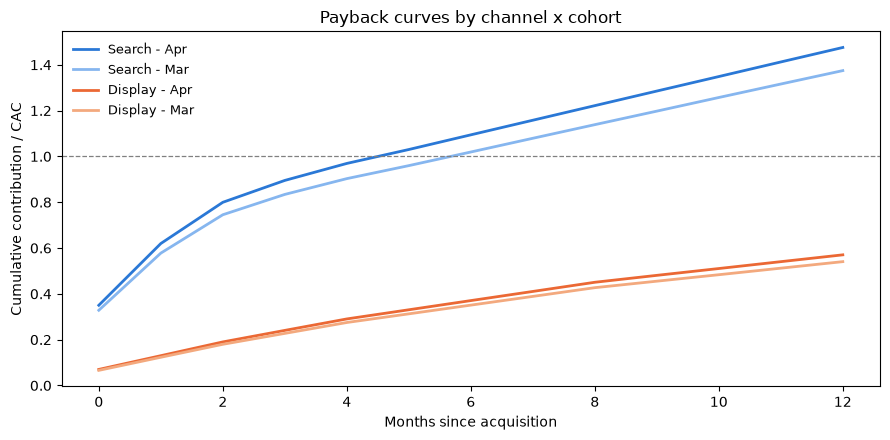

In [8]:
def payback_curve(channel, cohort_month, max_m=12):
    """채널×획득월 코호트의 회수 곡선(누적 공헌이익 ÷ CAC 총액)을 반환한다."""
    df = con.execute(f"""
        WITH cohort AS (
            SELECT user_id FROM users
            WHERE channel = '{channel}'
              AND date_trunc('month', signup_date) = DATE '{cohort_month}-01'
        ),
        cost AS (
            SELECT SUM(media_cost_krw + other_cost_krw) AS cac_total
            FROM marketing_costs
            WHERE channel = '{channel}' AND month = DATE '{cohort_month}-01'
        )
        SELECT date_diff('month', DATE '{cohort_month}-01',
                         date_trunc('month', p.payment_date)) AS m
             , SUM(p.amount_krw) * {CM_RATIO} / (SELECT cac_total FROM cost) AS r
        FROM payments p JOIN cohort USING (user_id)
        GROUP BY 1 ORDER BY 1 LIMIT {max_m + 1}
    """).df()
    return df.r.cumsum()

fig, ax = plt.subplots(figsize=(9, 4.5))
styles = [("search", "2025-04", "#2a78d6", "Search - Apr"),
          ("search", "2025-03", "#86b6ef", "Search - Mar"),
          ("display", "2025-04", "#eb6834", "Display - Apr"),
          ("display", "2025-03", "#f3a97e", "Display - Mar")]
for ch, cm, color, label in styles:
    y = payback_curve(ch, cm)
    ax.plot(range(len(y)), y, color=color, linewidth=2, label=label)
    cross = next((i for i, v in enumerate(y) if v >= 1), None)
    print(f"{label:<13}: payback = {'M+' + str(cross) + f' ({cross+1}개월째)' if cross else '미회수 (관측 구간 내)'}")

ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.9)
ax.set_xlabel("Months since acquisition")
ax.set_ylabel("Cumulative contribution / CAC")
ax.set_title("Payback curves by channel x cohort")
ax.legend(loc="upper left", frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

검색은 4월 코호트가 3월보다 한 달 빨리(6개월째 vs 7개월째) CAC에 도달했고, 디스플레이는
두 코호트 모두 관측 구간 안에서 CAC를 회수하지 못했습니다. LTV:CAC 비율이 같아도 회수
'속도'는 코호트마다 다를 수 있기 때문에 숫자 하나가 아니라 차트를 직접 그려서 확인해 보는
것이 좋습니다.

### 5) Payback 기반 CAC 가이드라인

마지막으로 CAC 가이드라인 = 목표 Payback Period × 유저당 월평균 공헌이익 공식에 따라
각 채널별 타겟 CAC를 구해 보겠습니다. 월평균 공헌이익은 성숙 코호트의 첫 12개월 실측으로
계산합니다.

In [9]:
monthly = con.execute(f"""
WITH mature AS (
    SELECT user_id, channel, date_trunc('month', signup_date) AS cohort_month
    FROM users WHERE signup_date < DATE '2023-07-01'
)
SELECT m.channel
     , SUM(p.amount_krw) * {CM_RATIO}
       / COUNT(DISTINCT m.user_id) / 12.0 AS avg_monthly_contrib   -- 첫 12개월 월평균
FROM mature m
JOIN payments p
  ON p.user_id = m.user_id
 AND p.payment_date < m.cohort_month + INTERVAL 12 MONTH
WHERE m.channel != 'organic'
GROUP BY 1
""").df()

TARGET_PAYBACK = 8   # 목표 회수 기간(개월) — 경영 의사결정의 영역
guide = monthly.merge(cac[["channel", "cac_fully_loaded"]], on="channel")
guide["avg_monthly_contrib"] = guide.avg_monthly_contrib.round(0)
guide["cac_guideline"] = (guide.avg_monthly_contrib * TARGET_PAYBACK).round(-2)
guide["current_vs_guide"] = (guide.cac_fully_loaded / guide.cac_guideline).round(2)
guide[["channel", "avg_monthly_contrib", "cac_guideline",
       "cac_fully_loaded", "current_vs_guide"]].sort_values("current_vs_guide")

,channel,avg_monthly_contrib,cac_guideline,cac_fully_loaded,current_vs_guide
1,retargeting,1659.0,13300.0,3600.0,0.27
3,search,1358.0,10900.0,11500.0,1.06
2,display,323.0,2600.0,5700.0,2.19
0,brand,1014.0,8100.0,28000.0,3.46


목표 Payback을 8개월로 두면 리타겟팅을 제외한 검색, 디스플레이, 브랜드 광고 모두 CAC
가이드라인을 초과합니다. 본문에서 이야기 한 것 처럼 목표 기간이 바뀌면 채널의 효율이
동일하다고 하더라도 CAC 가이드라인 준수 여부는 달라질 수 있습니다. (`TARGET_PAYBACK`을
12로 바꿔서 다시 실행해 보세요.)